# Probability-Flow ODE - Part 6
## A worked example: train a small network and generate a Gaussian mixture

**Draft · Probability-Flow ODE · Part 06.** This notebook completes the construction in Part 3: choose a forward process, generate regression examples, estimate its score, construct its velocity, and solve the ODE backward. Every experiment is one-dimensional and runs on a laptop CPU. No dataset or pretrained model download is needed.

The primary reference is [Song et al., *Score-Based Generative Modeling through Stochastic Differential Equations*](https://arxiv.org/abs/2011.13456v2): Eq. (7) for training, Eq. (13) for the probability-flow ODE, and Appendix B for VP schedules. Our small MLP and synthetic experiments are teaching examples, not a reproduction of the paper's image results.

Run all cells in order. Install `numpy scipy matplotlib torch nbformat nbclient ipykernel` in the selected Python environment. The saved outputs let you read the notebook without rerunning it. The default trains for 8,000 updates; reduce this for a quick code check, but expect worse sample fidelity.

## 1. Define the data distribution

We choose a smooth, equally weighted mixture:

$$p_0(x)=\tfrac12\mathcal N(x;-2,0.25)+\tfrac12\mathcal N(x;2,0.25).$$

The second Gaussian parameter is **variance**, so each component has standard deviation 0.5. The mixture has mean zero and variance $0.25+2^2=4.25$. Two separated modes make failure to capture one mode visible.

We simulate a finite training dataset, an independent validation dataset, and independent evaluation observations. Training uses only clean samples, not the analytic density or score. Separate random generators keep evaluation draws independent of how many training updates we run.


Training mean and variance: 0.005098354537039995 4.231892108917236
Versions: NumPy 2.0.2 PyTorch 2.8.0 SciPy 1.13.1


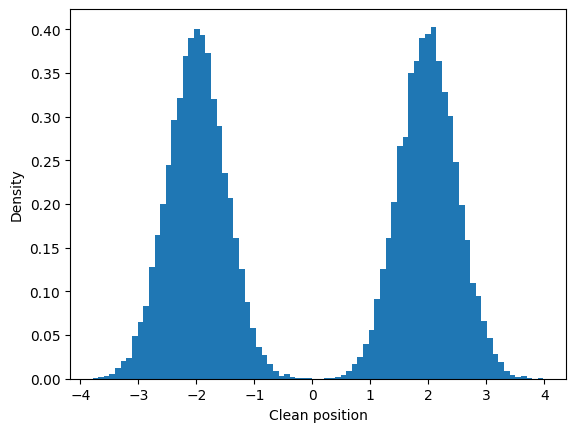

In [1]:
import copy, time
import numpy as np
import scipy
import torch
from torch import nn
import matplotlib.pyplot as plt
from scipy.special import logsumexp, ndtr, ndtri
from scipy.optimize import brentq

started = time.perf_counter()
torch.set_num_threads(2)
torch.manual_seed(20261006)
train_rng = np.random.default_rng(101)
validation_rng = np.random.default_rng(102)
weights = np.array([0.5, 0.5])
means = np.array([-2.0, 2.0])
variances = np.array([0.25, 0.25])

def draw_data(n, rng):
    j = rng.choice(len(weights), size=n, p=weights)
    return means[j] + np.sqrt(variances[j])*rng.normal(size=n)

training_data = torch.tensor(draw_data(30000, train_rng), dtype=torch.float32)
validation_data = torch.tensor(draw_data(5000, validation_rng), dtype=torch.float32)
print('Training mean and variance:', training_data.mean().item(), training_data.var().item())
print('Versions:', 'NumPy', np.__version__, 'PyTorch', torch.__version__, 'SciPy', scipy.__version__)
plt.hist(training_data.numpy(), bins=80, density=True)
plt.xlabel('Clean position'); plt.ylabel('Density'); plt.show()


## 2. Fix one schedule for training and inference

The forward VP SDE and its conditional law are

$$dX_t=-\frac{\beta(t)}2X_t\,dt+\sqrt{\beta(t)}\,dW_t,$$
$$X_t\mid X_0=x_0\sim\mathcal N(\alpha_tx_0,1-\alpha_t^2),\qquad
\alpha_t=\exp\left[-\frac12\int_0^t\beta(u)du\right].$$

Use the paper's linear rate $\beta(t)=0.1+19.9t$. Then

$$\alpha_t=\exp[-0.05t-4.975t^2].$$

Time 0 means clean data; time 1 means the terminal law. The one-shot corruption samples the conditional distribution without numerically simulating an SDE. The accumulated noise standard deviation is $\sqrt{1-\alpha_t^2}$, not $\sqrt{\beta(t)}$.

We stop generation at $t_{\min}=0.001$, the lower edge of the training range. Its intended output is $p_{0.001}$, a slightly smoothed version of $p_0$. Keep this distinction in every density comparison. Schedule constants below must not change after training.


In [2]:
BETA_MIN, BETA_MAX = 0.1, 20.0
T_MIN = 1e-3

def beta(t):
    return BETA_MIN + (BETA_MAX-BETA_MIN)*t

def coefficients(t):
    # Supports both torch tensors and NumPy arrays/scalars.
    B = BETA_MIN*t + 0.5*(BETA_MAX-BETA_MIN)*t**2
    if torch.is_tensor(t):
        return torch.exp(-0.5*B), torch.sqrt(-torch.expm1(-B))
    return np.exp(-0.5*B), np.sqrt(-np.expm1(-B))

t_check = torch.tensor([.001, .1, .5, 1.], dtype=torch.float64, requires_grad=True)
a, noise_std = coefficients(t_check)
da = torch.autograd.grad(a.sum(), t_check)[0]
assert torch.allclose(da, -0.5*beta(t_check)*a)
assert torch.allclose(a*a+noise_std*noise_std, torch.ones_like(a))
print('Terminal amplitude:', float(coefficients(1.)[0]))
print('Stopping-time noise standard deviation:', float(coefficients(T_MIN)[1]))


Terminal amplitude: 0.006571586494929619
Stopping-time noise standard deviation: 0.010485416335094895


## 3. Derive reference densities and scores for evaluation

Gaussian corruption preserves the mixture structure. Component $j$ has

$$m_{t,j}=\alpha_tm_j,\qquad V_{t,j}=\alpha_t^2V_j+1-\alpha_t^2.$$

Its conditional component probability given $x$ is

$$w_j(x,t)=\frac{w_j\mathcal N(x;m_{t,j},V_{t,j})}{p_t(x)}.$$

Differentiating the mixture gives the marginal score

$$s_t(x)=\sum_jw_j(x,t)\frac{m_{t,j}-x}{V_{t,j}}.$$

We also know $F_t(x)=\sum_jw_j\Phi((x-m_{t,j})/\sqrt{V_{t,j}})$. These analytic functions are **evaluation references only**. The network never receives their score values as targets. Log-sum-exp stabilizes responsibilities in low-density regions.


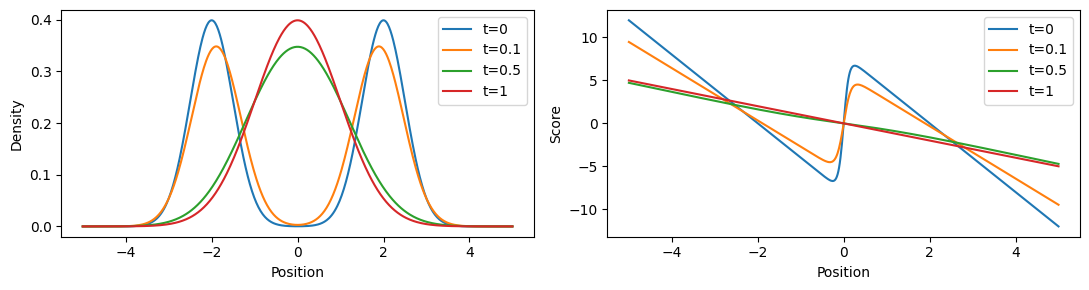

In [3]:
def marginal_parameters(t):
    a, sigma = coefficients(t)
    return a*means, a*a*variances + sigma*sigma

def component_logs(x, t):
    m, V = marginal_parameters(t)
    return np.log(weights)-0.5*np.log(2*np.pi*V)-(np.asarray(x)[..., None]-m)**2/(2*V)

def density(x, t):
    return np.exp(logsumexp(component_logs(x,t), axis=-1))

def exact_score(x, t):
    m, V = marginal_parameters(t)
    logs = component_logs(x,t)
    responsibility = np.exp(logs-logsumexp(logs,axis=-1,keepdims=True))
    return np.sum(responsibility*(m-np.asarray(x)[...,None])/V, axis=-1)

def cdf(x, t):
    m, V = marginal_parameters(t)
    return np.sum(weights*ndtr((np.asarray(x)[...,None]-m)/np.sqrt(V)), axis=-1)

def draw_marginal(n, t, rng):
    a, sigma = coefficients(t)
    return a*draw_data(n,rng)+sigma*rng.normal(size=n)

grid = np.linspace(-5,5,600)
delta = 1e-5
numerical_score = (np.log(density(grid+delta,.2))-np.log(density(grid-delta,.2)))/(2*delta)
assert np.max(np.abs(numerical_score-exact_score(grid,.2))) < 1e-6
fig, axes = plt.subplots(1,2,figsize=(11,3))
for t in [0., .1, .5, 1.]:
    axes[0].plot(grid,density(grid,t),label=f't={t:g}')
    axes[1].plot(grid,exact_score(grid,t),label=f't={t:g}')
axes[0].set(xlabel='Position',ylabel='Density'); axes[1].set(xlabel='Position',ylabel='Score')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()


The density starts with two modes and becomes nearly Gaussian. The score changes with time, so time must be a network input. The exact terminal law remains a Gaussian **mixture**, even though it is close to $\mathcal N(0,1)$. Below we first initialize from the actual $p_1$ to keep the analytic sampling argument matched, and then measure the effect of substituting a standard Gaussian.

## 4. Generate noisy regression pairs

Draw independently

$$t\sim U[t_{\min},1],\quad X_0\sim\widehat P_{\mathrm{train}},\quad
\varepsilon\sim\mathcal N(0,1),$$

and construct $X_t=\alpha_tX_0+\sqrt{1-\alpha_t^2}\varepsilon$. Train a noise predictor using

$$\mathcal L(\theta)=\mathbb E_{t,X_0,\varepsilon}
[(\varepsilon_\theta(X_t,t)-\varepsilon)^2].$$

The network inputs are $(X_t,t)$; the target is the particular noise draw used in that example. The population optimum is $\mathbb E[\varepsilon\mid X_t=x,t]$, giving

$$s_\theta(x,t)=-\frac{\varepsilon_\theta(x,t)}{\sqrt{1-\alpha_t^2}}.$$

This is Song's denoising score objective reparameterized by Gaussian noise, with weight $\lambda(t)=1-\alpha_t^2$ and a positive-time cutoff. Gaussian targets have second moment 1 at every time; the conditional score target has second moment $1/(1-\alpha_t^2)$. Noise prediction controls target scale, but conversion can still amplify low-noise errors. The unknown posterior is used to characterize the optimum, never evaluated during training.


For this finite training set, the regression optimum is the posterior mean under the corrupted **empirical** distribution. Its scaled output is the score of that smoothed empirical law; this approximates the population score when the dataset is representative. Finite-data differences matter especially at low noise and in sparse tails.

The individual direct-score label is $-\varepsilon/\sqrt{1-\alpha_t^2}$, a **conditional score**. Its regression prediction is the **marginal score**, obtained by averaging conditional on the input $(X_t,t)$. A noise predictor estimates the corresponding conditional mean of noise, not the particular noise draw. Even a zero-noise training pair can have a nonzero optimal prediction at its noisy input; Part 3 gives an explicit Gaussian example.


Sampling from the actual population terminal mixture is available here only because we know the synthetic data generator. We use it as a diagnostic initialization. A separate learned-field run below starts from standard Gaussian noise and requires no clean-data generator at inference.


In [4]:
class NoiseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(6,64),nn.SiLU(),
                                 nn.Linear(64,64),nn.SiLU(),nn.Linear(64,1))
    def forward(self,x,t):
        features = torch.stack([x,t,torch.sin(np.pi*t),torch.cos(np.pi*t),
                                torch.sin(2*np.pi*t),torch.cos(2*np.pi*t)],dim=-1)
        return self.net(features).squeeze(-1)

# Fixed validation corruption: independent from training minibatches.
val_generator = torch.Generator().manual_seed(104)
val_t = T_MIN+(1-T_MIN)*torch.rand(len(validation_data),generator=val_generator)
val_eps = torch.randn(len(validation_data),generator=val_generator)
val_a,val_sigma = coefficients(val_t)
val_xt = val_a*validation_data+val_sigma*val_eps
print('Trainable parameters:', sum(p.numel() for p in NoiseNet().parameters()))


Trainable parameters: 4673


## 5. Train the small network

Each update samples clean observations with replacement, generates fresh times and Gaussian noise, computes the minibatch MSE, and takes an Adam step. The sinusoidal time features are fixed inputs, not learned schedule coefficients.

We keep an exponential moving average (EMA) of network parameters to reduce variation between updates. Every 500 updates and at the final update, we measure its noise MSE on the fixed validation corruption and retain the best validation checkpoint. Neither validation nor checkpoint selection uses the analytic score. This modest teaching budget is not guaranteed to converge to the population optimum; the diagnostics below measure its remaining errors.


For context, we also evaluate the analytic population-optimal noise predictor on the same validation pairs, after training. Its observed loss estimates an irreducible-risk reference; it is not an exact finite-sample lower bound or the empirical-training optimum. Neither it nor the analytic score is used for checkpoint selection. A final-step best checkpoint alone does not establish whether training has plateaued.


Training seconds: 3.0
Best validation noise MSE / update: 0.30686137080192566 8000


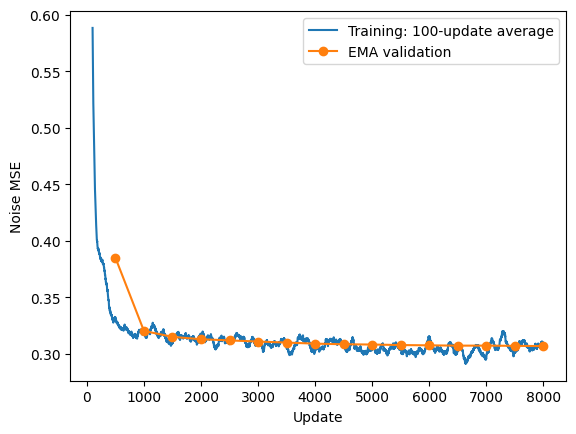

Population-oracle validation noise MSE: 0.3042731330683329
Model minus oracle validation MSE: 0.0025882377335927353
Best checkpoint is final checkpoint: True


In [5]:
torch.manual_seed(105)
model = NoiseNet()
ema = copy.deepcopy(model)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
UPDATES, BATCH_SIZE = 8000, 512
losses, validation_log = [], []
assert UPDATES >= 1
best_validation, best_state, best_update = float('inf'), None, None
training_start = time.perf_counter()
for update in range(1,UPDATES+1):
    model.train()
    indices = torch.randint(len(training_data),(BATCH_SIZE,))
    x0 = training_data[indices]
    t = T_MIN+(1-T_MIN)*torch.rand(BATCH_SIZE)
    eps = torch.randn(BATCH_SIZE)
    a,sigma = coefficients(t)
    xt = a*x0+sigma*eps
    loss = (model(xt,t)-eps).square().mean()
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    with torch.no_grad():
        for averaged,current in zip(ema.parameters(),model.parameters()):
            averaged.lerp_(current,0.005)
    if update % 500 == 0 or update == UPDATES:
        ema.eval()
        with torch.no_grad(): value=(ema(val_xt,val_t)-val_eps).square().mean().item()
        validation_log.append((update,value))
        if value < best_validation:
            best_validation=value
            best_update=update
            best_state=copy.deepcopy(ema.state_dict())
# Inference uses the selected EMA weights, not the final raw weights.
model.load_state_dict(best_state)
model.eval()
print(f'Training seconds: {time.perf_counter()-training_start:.1f}')
print('Best validation noise MSE / update:',best_validation,best_update)
window=min(100,UPDATES)
smoothed=np.convolve(losses,np.ones(window)/window,mode='valid')
plt.plot(np.arange(window,UPDATES+1),smoothed,label=f'Training: {window}-update average')
vlog=np.asarray(validation_log)
plt.plot(vlog[:,0],vlog[:,1],'o-',label='EMA validation')
plt.xlabel('Update');plt.ylabel('Noise MSE');plt.legend();plt.show()

# Evaluation only: the population-optimal noise predictor on the same validation pairs.
val_exact_eps=-val_sigma.numpy()*np.array([exact_score(x,t) for x,t in zip(val_xt.numpy(),val_t.numpy())])
exact_validation=float(np.mean((val_exact_eps-val_eps.numpy())**2))
print('Population-oracle validation noise MSE:',exact_validation)
print('Model minus oracle validation MSE:',best_validation-exact_validation)
print('Best checkpoint is final checkpoint:',best_update==UPDATES)


## 6. Check the learned score before sampling

At each fixed time, measure

$$\operatorname{MSE}(t)=\mathbb E_{X_t\sim p_t}[(s_\theta(X_t,t)-s_t(X_t))^2].$$

The expectation is over independent noisy evaluation observations, not a uniform grid. Grid plots show the shape; marginal-weighted MSE measures error where probability mass lies. Include $t=0.001$ and $0.01$ because these low-noise scores are the most sensitive to the division by noise standard deviation. A good average noise loss can coexist with visibly worse score accuracy there.


Also report $(1-\alpha_t^2)\operatorname{MSE}(t)$, the squared error in **conditional-mean noise units**. This compares the model to the optimal noise predictor, not to an individual noise draw; the latter loss includes irreducible conditional variance. Each diagnostic cell resets its own evaluation generator, so rerunning a plot does not change the terminal particles.


t=0.001  score MSE=191.879648  noise-scale MSE=0.021096
t=0.010  score MSE=5.369560  noise-scale MSE=0.010702
t=0.100  score MSE=0.038962  noise-scale MSE=0.004041
t=0.500  score MSE=0.000394  noise-scale MSE=0.000363
t=0.900  score MSE=0.000173  noise-scale MSE=0.000173


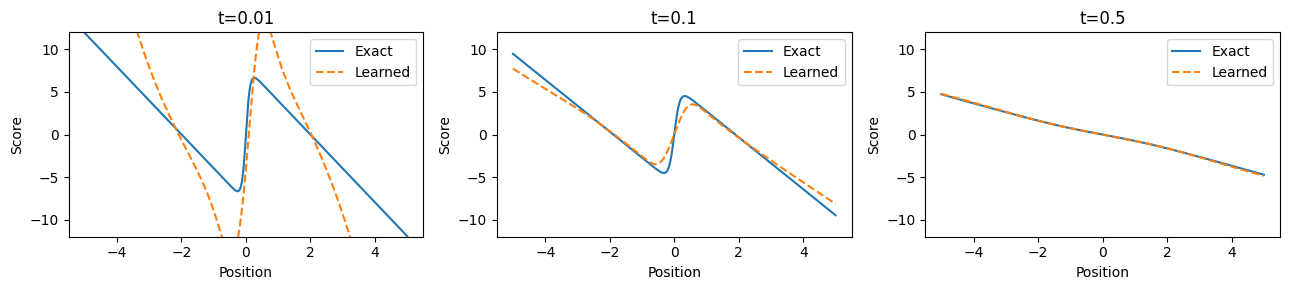

In [11]:
@torch.no_grad()
def learned_score(x,t):
    xx=torch.as_tensor(np.asarray(x),dtype=torch.float32)
    tt=torch.full_like(xx,float(t))
    return -model(xx,tt).numpy()/coefficients(float(t))[1]

fig,axes=plt.subplots(1,3,figsize=(13,3))
score_results=[]
score_rng=np.random.default_rng(103)
for t in [T_MIN,.01,.1,.5,.9]:
    x=draw_marginal(5000,t,score_rng)
    mse=np.mean((learned_score(x,t)-exact_score(x,t))**2)
    score_results.append((t,float(mse)))
    noise_mse=coefficients(t)[1]**2*mse
    print(f't={t:.3f}  score MSE={mse:.6f}  noise-scale MSE={noise_mse:.6f}')
for ax,t in zip(axes,[.01,.1,.5,0.9]):
    ax.plot(grid,exact_score(grid,t),label='Exact')
    ax.plot(grid,learned_score(grid,t),'--',label='Learned')
    ax.set(xlabel='Position',ylabel='Score',title=f't={t:g}',ylim=(-12,12))
    ax.legend()
plt.tight_layout();plt.show()


## 7. Construct the field and integrate backward

Use the **same** rate and conditional noise scale as training:

$$v_\theta(x,t)=-\frac{\beta(t)}2[x+s_\theta(x,t)].$$

For $h=t_k-t_{k+1}>0$, explicit Euler with decreasing time gives

$$x_{k+1}=x_k-hv_\theta(x_k,t_k)
=x_k+\frac{h\beta(t_k)}2[x_k+s_\theta(x_k,t_k)].$$

There is no fresh noise in this ODE loop. The random initial particle supplies the sampling randomness. This is not the implicit backward-Euler method and not Euler–Maruyama.

We compare exact and learned fields using identical draws from the actual terminal mixture $p_1$. Thus both runs solve the same endpoint problem; their difference reflects field estimation together with its interaction with discretization.


Last score evaluation time: 0.001998999999999862 ; output time: 0.001
Matched sampling runs, seconds: 0.8


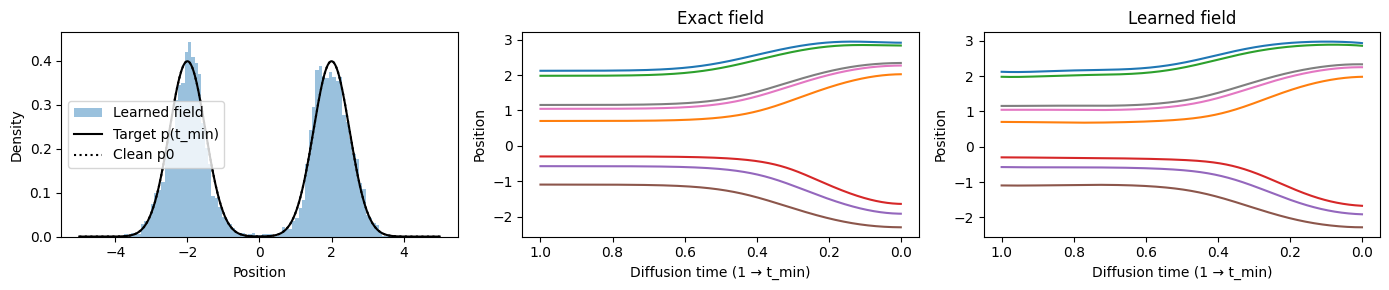

Practical learned-field run starts from N(0,1).


In [7]:
def euler_reverse(x1,score_fn,steps=1000,end=T_MIN,keep=8):
    x=np.asarray(x1,dtype=np.float64).copy()
    times=np.linspace(1.,end,steps+1)
    paths=[x[:keep].copy()]
    for t,next_t in zip(times[:-1],times[1:]):
        x += 0.5*(t-next_t)*beta(t)*(x+score_fn(x,t))
        paths.append(x[:keep].copy())
    if not np.isfinite(x).all(): raise FloatingPointError('Non-finite Euler output')
    return x,times,np.asarray(paths)

terminal_rng=np.random.default_rng(106)
x1=draw_marginal(6000,1.,terminal_rng)
sampling_start=time.perf_counter()
exact_samples,times,exact_paths=euler_reverse(x1,exact_score)
generated,_,learned_paths=euler_reverse(x1,learned_score)
print('Last score evaluation time:',times[-2], '; output time:',times[-1])
print(f'Matched sampling runs, seconds: {time.perf_counter()-sampling_start:.1f}')
fig,axes=plt.subplots(1,3,figsize=(14,3))
axes[0].hist(generated,bins=80,density=True,alpha=.45,label='Learned field')
axes[0].plot(grid,density(grid,T_MIN),'k',label='Target p(t_min)')
axes[0].plot(grid,density(grid,0),'k:',label='Clean p0');axes[0].legend()
axes[0].set(xlabel='Position',ylabel='Density')
for ax,paths,label in zip(axes[1:],[exact_paths,learned_paths],['Exact field','Learned field']):
    ax.plot(times,paths);ax.invert_xaxis()
    ax.set(xlabel='Diffusion time (1 → t_min)',ylabel='Position',title=label)
plt.tight_layout();plt.show()

# Practical generation: no oracle data generator is used for initialization.
prior_rng=np.random.default_rng(109)
gaussian_x1=prior_rng.normal(size=len(x1))
practical_samples,_,_=euler_reverse(gaussian_x1,learned_score)
print('Practical learned-field run starts from N(0,1).')


## 8. Measure fidelity, not just visual resemblance

For output samples, compare mean, variance, left-mode probability $P(X<0)$, and empirical CDF discrepancy

$$D=\sup_x|\widehat F_{\rm samples}(x)-F_{t_{\min}}(x)|.$$

Also compare the empirical Wasserstein-1 distance to an independent reference draw: sort equally sized arrays and average the absolute paired difference. Even direct reference samples have nonzero empirical discrepancies. For our symmetric mixture, the target mean is 0, variance is $1+3.25\alpha_t^2$, and $P(X<0)=1/2$.

The exact-field run measures numerical and Monte Carlo effects. The learned-field run adds score estimation error. The direct-draw baseline calibrates finite-sample variation. None of these comparisons claims exact sampling from clean $p_0$ when stopping at positive time.


The practical learned-field run uses a separate standard-normal initialization. Its difference from the matched learned run combines prior substitution and different initial Monte Carlo draws; the deterministic quantile experiment in Section 9 isolates prior substitution.


Target mean/variance/left mass: 0.0 4.249642682143909 0.5
Method                  mean  variance  left mass        KS        W1
Direct draw         -0.04311   4.25828   0.51117   0.01475   0.04656
Exact field          0.03170   4.26958   0.49583   0.01690   0.03758
Learned field        0.03824   4.24887   0.49083   0.01746   0.04980
Learned + N(0,1)     0.03287   4.20538   0.48517   0.02107   0.06734
Paired learned/exact output MAE: 0.03442406902303831
Learned-output KS against clean p0: 0.017430836422950624


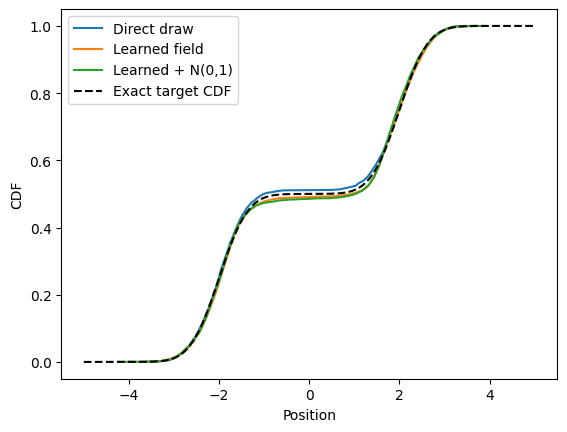

Direct-draw KS 5/50/95 percentiles (100 replicates): [0.00639322 0.01025589 0.01646729]


In [8]:
def ks_error(x,t):
    ordered=np.sort(x);F=cdf(ordered,t);n=len(x)
    return max(np.max(np.arange(1,n+1)/n-F),np.max(F-np.arange(n)/n))

reference_rng=np.random.default_rng(107)
reference=draw_marginal(len(generated),T_MIN,reference_rng)
baseline=draw_marginal(len(generated),T_MIN,reference_rng)
metrics={}
target_m,target_V=marginal_parameters(T_MIN)
target_mean=np.sum(weights*target_m)
target_var=np.sum(weights*(target_V+target_m**2))-target_mean**2
print('Target mean/variance/left mass:',target_mean,target_var,cdf(0.,T_MIN))
print(f"{'Method':18s} {'mean':>9s} {'variance':>9s} {'left mass':>10s} {'KS':>9s} {'W1':>9s}")
for name,x in [('Direct draw',baseline),('Exact field',exact_samples),('Learned field',generated),('Learned + N(0,1)',practical_samples)]:
    values=[np.mean(x),np.var(x),np.mean(x<0),ks_error(x,T_MIN),np.mean(abs(np.sort(x)-np.sort(reference)))]
    metrics[name]=list(map(float,values))
    print(f'{name:18s}'+''.join(f'{v:10.5f}' for v in values))
print('Paired learned/exact output MAE:',np.mean(abs(generated-exact_samples)))
print('Learned-output KS against clean p0:',ks_error(generated,0.))
for name,x in [('Direct draw',baseline),('Learned field',generated),('Learned + N(0,1)',practical_samples)]:
    xx=np.sort(x);plt.plot(xx,np.arange(1,len(xx)+1)/len(xx),label=name)
plt.plot(grid,cdf(grid,T_MIN),'k--',label='Exact target CDF')
plt.xlabel('Position');plt.ylabel('CDF');plt.legend();plt.show()

# Repeated direct draws calibrate sampling variation, not a fixed error floor.
calibration_rng=np.random.default_rng(108)
ks_baselines=np.array([ks_error(draw_marginal(len(generated),T_MIN,calibration_rng),T_MIN) for _ in range(100)])
print('Direct-draw KS 5/50/95 percentiles (100 replicates):',np.quantile(ks_baselines,[.05,.5,.95]))


## 9. Separate Euler error from terminal-prior substitution

In one dimension, a smooth ODE flow preserves quantile ranks. The exact transport from time 1 to $t_{\min}$ obeys

$$x_{t_{\min}}=F_{t_{\min}}^{-1}(F_1(x_1)).$$

Use deterministic quantiles instead of random particles to test Euler convergence with the analytic score. Then use the same quantile levels with $x_1=\Phi^{-1}(u)$ to isolate replacing the true terminal mixture with standard normal. This replacement is a separate approximation, not a change to the score or schedule. In a real dataset, exact $p_1$ may not be available; the experiment is possible here because the synthetic reference is known.


In [9]:
u=(np.arange(400)+.5)/400
terminal_quantiles=np.array([brentq(lambda x:cdf(x,1.)-q,-12,12) for q in u])
target_quantiles=np.array([brentq(lambda x:cdf(x,T_MIN)-q,-12,12) for q in u])
convergence=[]
for steps in [100,250,500,1000]:
    result,_,_=euler_reverse(terminal_quantiles,exact_score,steps=steps)
    err=float(np.mean(abs(result-target_quantiles)))
    convergence.append((steps,err));print('Steps / exact-field endpoint MAE:',steps,err)
assert convergence[-1][1] < convergence[0][1]
normal_result,_,_=euler_reverse(ndtri(u),exact_score)
matched_result,_,_=euler_reverse(terminal_quantiles,exact_score)
print('Paired effect of Gaussian prior substitution:',np.mean(abs(normal_result-matched_result)))
print(f'Total notebook runtime: {time.perf_counter()-started:.1f} seconds')

print('Endpoint comparison: learned KS at cutoff / clean:',ks_error(generated,T_MIN),ks_error(generated,0.))
print('Paired learned-field / Euler / prior MAE:',np.mean(abs(generated-exact_samples)),convergence[-1][1],np.mean(abs(normal_result-matched_result)))

# Known CDFs isolate endpoint smoothing without sample variation.
endpoint_grid=np.linspace(-8,8,50001)
cutoff_cdf_gap=float(np.max(abs(cdf(endpoint_grid,T_MIN)-cdf(endpoint_grid,0.))))
print('Grid estimate of sup |F_cutoff - F_clean|:',cutoff_cdf_gap)
print('Initial terminal-draw KS:',ks_error(x1,1.))
print('Exact-field output KS:',ks_error(exact_samples,T_MIN))


Steps / exact-field endpoint MAE: 100 0.003857469542527785
Steps / exact-field endpoint MAE: 250 0.0015352161414551749
Steps / exact-field endpoint MAE: 500 0.0007664065121784339
Steps / exact-field endpoint MAE: 1000 0.00038290560218215837
Paired effect of Gaussian prior substitution: 4.1312197810302874e-05
Total notebook runtime: 5.4 seconds
Endpoint comparison: learned KS at cutoff / clean: 0.01746349968477845 0.017430836422950624
Paired learned-field / Euler / prior MAE: 0.03442406902303831 0.00038290560218215837 4.1312197810302874e-05
Grid estimate of sup |F_cutoff - F_clean|: 5.326065784638789e-05
Initial terminal-draw KS: 0.016774445209343125
Exact-field output KS: 0.01689815709305298


### Interpreting the results

Start with the paired learned/exact output MAE: both solvers start from the same particles, so this comparison exposes the change caused by the learned field at the chosen step size. The independent direct-draw KS baseline is one realization of sampling variation, not an accuracy floor. The repeated-baseline percentiles above give its scale; agreement on a few sample statistics does not establish equality of distributions.

The lowest-noise score can be poorly estimated despite reasonable final sample fidelity. Compare score MSE with noise-scale MSE: dividing by a small noise standard deviation amplifies prediction error. The default explicit Euler loop stops at $t=0.001$ but last **evaluates** the score at $t=0.001999$; it never queries the endpoint itself.

To understand accumulation, write $\sigma_t=\sqrt{1-\alpha_t^2}$ and $\delta\varepsilon=\varepsilon_\theta-\varepsilon_*$. At a fixed position, the velocity error is $\delta v=\beta(t)\delta\varepsilon/(2\sigma_t)$. Since

$$\frac{d\sigma_t}{dt}=\frac{\beta(t)(1-\sigma_t^2)}{2\sigma_t},$$

the local error contribution has weight $d\sigma_t/(1-\sigma_t^2)$, approximately $d\sigma_t$ at low noise. A large pointwise score error therefore need not produce a comparably large integrated displacement over a short low-noise interval. This is an explanation of the weighting, **not an endpoint-error bound**: trajectories change, errors vary along them, and the dynamics can amplify perturbations. The plotted marginal MSE alone cannot identify which time interval causes most endpoint error.

Use the grid comparison of the two known CDFs to measure endpoint smoothing separately from sampling variation. The two sample KS values against $p_{t_{\min}}$ and $p_0$ cannot resolve a gap much smaller than their Monte Carlo scale; a smaller KS against the clean law does not establish that the solver targets it. The final diagnostic below prints their sizes alongside Euler and learned-field differences. These effects depend on the schedule, cutoff, and data distribution; they need not remain small in other experiments. More Euler steps address integration error, not a systematically inaccurate score.

For an exact increasing one-dimensional transport, $F_{t_{\min}}(x_{t_{\min}})=F_1(x_1)$, so the empirical KS discrepancy is preserved from the initial draw to the final cloud. The printed initial KS helps explain an unusually high exact-field row; Euler discretization can change it. A direct-draw 95th percentile is not a hard quality threshold. Compare paired learned/exact outputs as well as distributional metrics; subtracting their KS statistics is not a direct measure of field error.

The known-CDF endpoint gap and exact-field prior-substitution error are small in this example. The practical learned-field/standard-normal run is also reported explicitly. Its accuracy is measured, not guaranteed by the small oracle prior-substitution result.

## 10. Other useful densities to try

These are suggested teaching experiments, ordered from simple checks to harder cases. Reinitialize and retrain the network after changing $P_0$; update every analytic reference and expected moment accordingly.

| Data density | What it tests | Reference considerations |
|---|---|---|
| $\mathcal N(2,1)$ | Sign, schedule, and terminal mean consistency | Analytic score and exact ODE trajectory |
| $\mathcal N(0,4)$ | Transport of variance | Analytic intermediate variance and score |
| $0.8\mathcal N(-2,0.25)+0.2\mathcal N(2,0.25)$ | Recovery of unequal mode mass | Reuse the Gaussian-mixture formulas; do not expect half the samples on each side |
| $0.5\mathcal N(-2,0.09)+0.5\mathcal N(2,1)$ | Narrow versus broad modes | Reuse the same formulas with component-specific variances |
| Three separated Gaussian components | Coverage of several modes | Extend the mixture arrays and responsibilities |
| Standard Laplace, $p_0(x)=\tfrac12e^{-|x|}$ | Sharp central peak and exponential tails | Positive-time score needs convolution/quadrature; variance is 2 |
| Student $t$ with 5 degrees of freedom | Heavier tails and rare observations | Finite variance $5/3$; use tail quantiles, and check terminal approximation carefully |
| Uniform on $[-2,2]$ | Bounded support and behavior near boundaries | Evaluate the smoothed positive-time density; do not expect a regular finite-time flow from a full-support prior to create exact hard boundaries |

For the next experiment, use **unequal mixture weights**: it changes one aspect while preserving tractable exact scores. Then use unequal component variances. Laplace is a useful later example once score estimation and endpoint conventions are clear.

### Exercises

1. Change only the terminal initialization and quantify its effect with matched quantiles.
2. Repeat learning with another training seed, keeping the evaluation observations fixed.
3. Change the mixture weights to 0.8 and 0.2. Use the exact CDF to compute the correct target left-side probability.
4. Lower the stopping time. Does a lower noise level improve clean-data fidelity, or does amplified score error offset that gain?
